# EEG preprocessing and SWD annotation

## Purpose
This notebook preprocesses individual EEG recordings and converts previously identified spike-and-wave discharge (SWD) timings from sample indices into MNE annotations.

For each EDF recording, the notebook:
1. loads the continuous EEG data;
2. verifies channel names and channel types;
3. relabels the ECG channel so that it is not treated as EEG;
4. applies a standard electrode montage and average reference;
5. applies 1–40 Hz band-pass and 50 Hz notch filtering for visual inspection;
6. converts SWD onset samples and durations into seconds;
7. attaches the SWD annotations to the recording;
8. visually checks the annotations; and
9. saves and reloads the annotation file to verify that it was written correctly.

## Inputs
- Continuous EEG recordings in EDF format.
- SWD onset samples and durations obtained from the corresponding marker files.
- Recording-specific sampling frequency read directly from each EDF file.

## Outputs
- One MNE `.fif` annotation file per EEG recording, named `<recording_id>_SWD_annotations.fif`.

## Reproducibility notes
- Replace the absolute local EDF paths with paths appropriate to the machine running the notebook.
- The code assumes that the ECG channel is named `ECG`.
- `on_missing='ignore'` allows montage assignment to continue when a channel name is not present in the standard montage; any ignored channels should therefore be checked.
- Filtering is used here to support visual review. The saved output contains annotations only, not a separately saved filtered EEG recording.
- No channels are manually marked as bad in this notebook.

## Software setup


In [1]:
# Install MNE if it is not already available in the active environment.
# For a fully reproducible repository, package installation is better handled
# through a requirements.txt or environment.yml file rather than inside the notebook.
!pip install mne

# Import the libraries used for EEG processing and file handling.
import mne
import os


In [2]:
# Record the installed MNE version used to run the analysis.
print(mne.__version__)


1.11.0


In [3]:
# Import NumPy for numerical arrays and record its installed version.
import numpy as np
print(np.__version__)


2.1.3


In [4]:
# Record the Python interpreter version used to run the notebook.
import sys
print(sys.version)


3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]


## Recording AC0003: load and test the workflow


In [ ]:
# Load the continuous EDF recording into memory.
# `preload=True` is required because the data are subsequently re-referenced
# and filtered in place. Update this absolute path before running elsewhere.
eeg_path = '/Users/X/Desktop/AB DISS/GSW/P001/EEG/export/20150122AC0003-edf_chin.edf'

raw = mne.io.read_raw_edf(eeg_path, preload=True)
raw


Extracting EDF parameters from /Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P001/EEG/export/20150122AC0003-edf_chin.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 168499  =      0.000 ...   673.996 secs...


<RawEDF | 20150122AC0003-edf_chin.edf, 64 x 168500 (674.0 s), ~82.3 MiB, data loaded>

### Channel configuration and montage


In [4]:
# checking the electrode system
raw.ch_names

['Fp1',
 'Fp2',
 'F3',
 'F4',
 'C3',
 'C4',
 'P3',
 'P4',
 'O1',
 'O2',
 'F7',
 'F8',
 'T7',
 'T8',
 'P7',
 'P8',
 'Fz',
 'Cz',
 'Pz',
 'Oz',
 'FC1',
 'FC2',
 'CP1',
 'CP2',
 'FC5',
 'FC6',
 'CP5',
 'CP6',
 'TP9',
 'TP10',
 'POz',
 'ECG',
 'F1',
 'F2',
 'C1',
 'C2',
 'P1',
 'P2',
 'AF3',
 'AF4',
 'FC3',
 'FC4',
 'CP3',
 'CP4',
 'PO3',
 'PO4',
 'F5',
 'F6',
 'C5',
 'C6',
 'P5',
 'P6',
 'AF7',
 'AF8',
 'FT7',
 'FT8',
 'TP7',
 'TP8',
 'PO7',
 'PO8',
 'FT9',
 'FT10',
 'Fpz',
 'CPz']

In [5]:
# Print each channel and its current MNE channel type.
# This check confirms whether non-EEG channels have been classified correctly.
for ch, typ in zip(raw.ch_names, raw.get_channel_types()):
    print(ch, typ)


Fp1 eeg
Fp2 eeg
F3 eeg
F4 eeg
C3 eeg
C4 eeg
P3 eeg
P4 eeg
O1 eeg
O2 eeg
F7 eeg
F8 eeg
T7 eeg
T8 eeg
P7 eeg
P8 eeg
Fz eeg
Cz eeg
Pz eeg
Oz eeg
FC1 eeg
FC2 eeg
CP1 eeg
CP2 eeg
FC5 eeg
FC6 eeg
CP5 eeg
CP6 eeg
TP9 eeg
TP10 eeg
POz eeg
ECG eeg
F1 eeg
F2 eeg
C1 eeg
C2 eeg
P1 eeg
P2 eeg
AF3 eeg
AF4 eeg
FC3 eeg
FC4 eeg
CP3 eeg
CP4 eeg
PO3 eeg
PO4 eeg
F5 eeg
F6 eeg
C5 eeg
C6 eeg
P5 eeg
P6 eeg
AF7 eeg
AF8 eeg
FT7 eeg
FT8 eeg
TP7 eeg
TP8 eeg
PO7 eeg
PO8 eeg
FT9 eeg
FT10 eeg
Fpz eeg
CPz eeg


In [6]:
# Reclassify the channel named `ECG` as electrocardiography rather than EEG.
# MNE operations restricted to EEG channels will then exclude this channel.
raw.set_channel_types({'ECG': 'ecg'})


<RawEDF | 20150122AC0003-edf_chin.edf, 64 x 168500 (674.0 s), ~82.3 MiB, data loaded>

In [7]:
# Print each channel and its current MNE channel type.
# This check confirms whether non-EEG channels have been classified correctly.
for ch, typ in zip(raw.ch_names, raw.get_channel_types()):
    print(ch, typ)


Fp1 eeg
Fp2 eeg
F3 eeg
F4 eeg
C3 eeg
C4 eeg
P3 eeg
P4 eeg
O1 eeg
O2 eeg
F7 eeg
F8 eeg
T7 eeg
T8 eeg
P7 eeg
P8 eeg
Fz eeg
Cz eeg
Pz eeg
Oz eeg
FC1 eeg
FC2 eeg
CP1 eeg
CP2 eeg
FC5 eeg
FC6 eeg
CP5 eeg
CP6 eeg
TP9 eeg
TP10 eeg
POz eeg
ECG ecg
F1 eeg
F2 eeg
C1 eeg
C2 eeg
P1 eeg
P2 eeg
AF3 eeg
AF4 eeg
FC3 eeg
FC4 eeg
CP3 eeg
CP4 eeg
PO3 eeg
PO4 eeg
F5 eeg
F6 eeg
C5 eeg
C6 eeg
P5 eeg
P6 eeg
AF7 eeg
AF8 eeg
FT7 eeg
FT8 eeg
TP7 eeg
TP8 eeg
PO7 eeg
PO8 eeg
FT9 eeg
FT10 eeg
Fpz eeg
CPz eeg


In [8]:
# Prepare the recording for visual review.
raw.set_channel_types({'ECG': 'ecg'})  # Exclude ECG from EEG-only operations.

# Assign standard electrode coordinates. The MNE `standard_1020` montage
# includes conventional 10-20 positions and additional extended positions.
# Unmatched channel names are retained without coordinates.
raw.set_montage('standard_1020', on_missing='ignore')

# Re-reference all EEG channels to their instantaneous average.
raw.set_eeg_reference('average')

# Retain frequencies between 1 and 40 Hz to reduce slow drift and
# high-frequency noise, then suppress 50 Hz UK mains interference.
raw.filter(l_freq=1.0, h_freq=40.0)
raw.notch_filter(freqs=50.0)


<RawEDF | 20150122AC0003-edf_chin.edf, 64 x 168500 (674.0 s), ~82.3 MiB, data loaded>

### EEG re-referencing


In [8]:
# Apply the average EEG reference directly to the data.
# `projection=False` performs the re-referencing immediately rather than
# storing it as a projection to be applied later.
raw.set_eeg_reference('average', projection=False)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawEDF | 20150122AC0003-edf_chin.edf, 64 x 168500 (674.0 s), ~82.3 MiB, data loaded>

### Filtering for visual inspection


In [9]:
# Apply a 1–40 Hz finite-impulse-response band-pass filter to reduce
# slow drift and high-frequency noise during visual inspection.
raw.filter(l_freq=1.0, h_freq=40.0, fir_design='firwin')

# Apply a 50 Hz notch filter to reduce UK mains interference.
raw.notch_filter(freqs=50.0)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge

<RawEDF | 20150122AC0003-edf_chin.edf, 64 x 168500 (674.0 s), ~82.3 MiB, data loaded>

### Consolidated preprocessing cell


In [9]:
# Re-run the preprocessing operations after reloading or resetting `raw`.
raw.set_eeg_reference('average')
raw.filter(l_freq=1.0, h_freq=40.0)
raw.notch_filter(freqs=50.0)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower pass

<RawEDF | 20150122AC0003-edf_chin.edf, 64 x 168500 (674.0 s), ~82.3 MiB, data loaded>

### Visual quality control


In [10]:
# Use the Qt backend so that MNE opens an interactive, scrollable EEG viewer.
# This requires a local graphical environment and a compatible Qt installation.
%matplotlib qt


### Convert marker timings into SWD annotations


In [11]:
# Read the sampling frequency from the current EDF file rather than
# assuming that all recordings use the same sampling rate.
sfreq = raw.info["sfreq"]

# Convert SWD onset positions and durations from samples, as supplied by the
# marker data, into seconds because MNE annotations use time in seconds.
onsets_sec = np.array([26566, 123241, 134099]) / sfreq
durations_sec = np.array([230, 4041, 7214]) / sfreq

# Create one annotation for each SWD interval. `orig_time` links the annotation
# timing to the recording measurement date when that metadata is available.
ann = mne.Annotations(
    onset=onsets_sec,
    duration=durations_sec,
    description=["SWD"] * len(onsets_sec),
    orig_time=raw.info["meas_date"]
)

# Attach the newly created SWD annotations to the current recording.
# This replaces any annotations that were previously attached to `raw`.
raw.set_annotations(ann)


<RawEDF | 20150122AC0003-edf_chin.edf, 64 x 168500 (674.0 s), ~82.3 MiB, data loaded>

Using matplotlib as 2D backend.


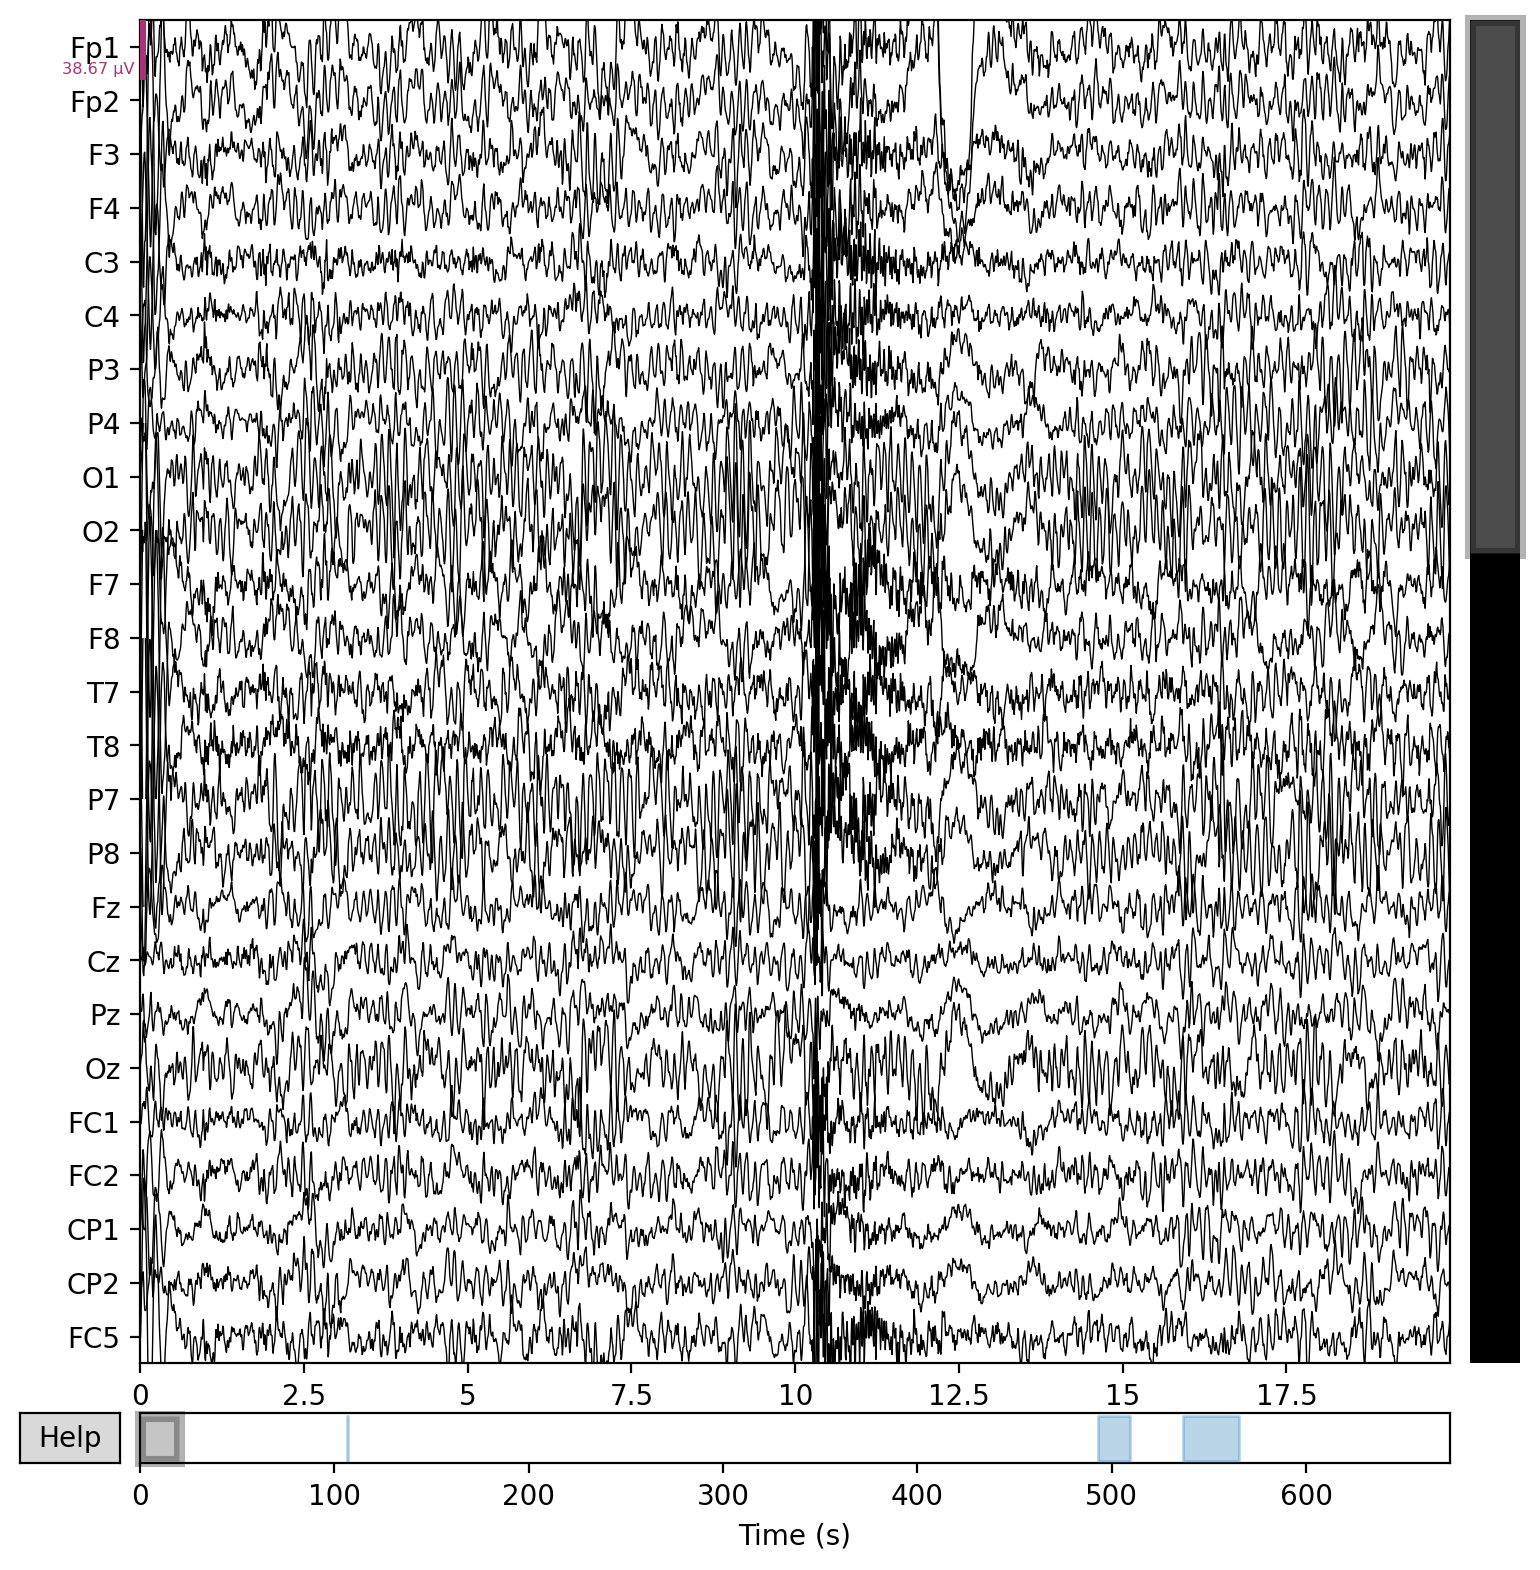

Channels marked as bad:
none


In [12]:
# Open the continuous recording for visual quality control.
# Only EEG channels are displayed; 20 seconds and 25 channels are shown at a time.
# Automatic scaling adjusts trace amplitudes for readability.
raw.plot(
    picks='eeg',
    duration=20,
    n_channels=25,
    scalings='auto'
)


In [13]:
# Checking all 3 SWD annotations are present 
print(raw.annotations)


<Annotations | 3 segments: SWD (3)>


In [14]:
# Count the SWD annotations attached to the current recording.
print(len(raw.annotations[raw.annotations.description == "SWD"]))


3

In [15]:
# Select only annotations labelled `SWD` for event-specific inspection.
swd = raw.annotations[raw.annotations.description == "SWD"]


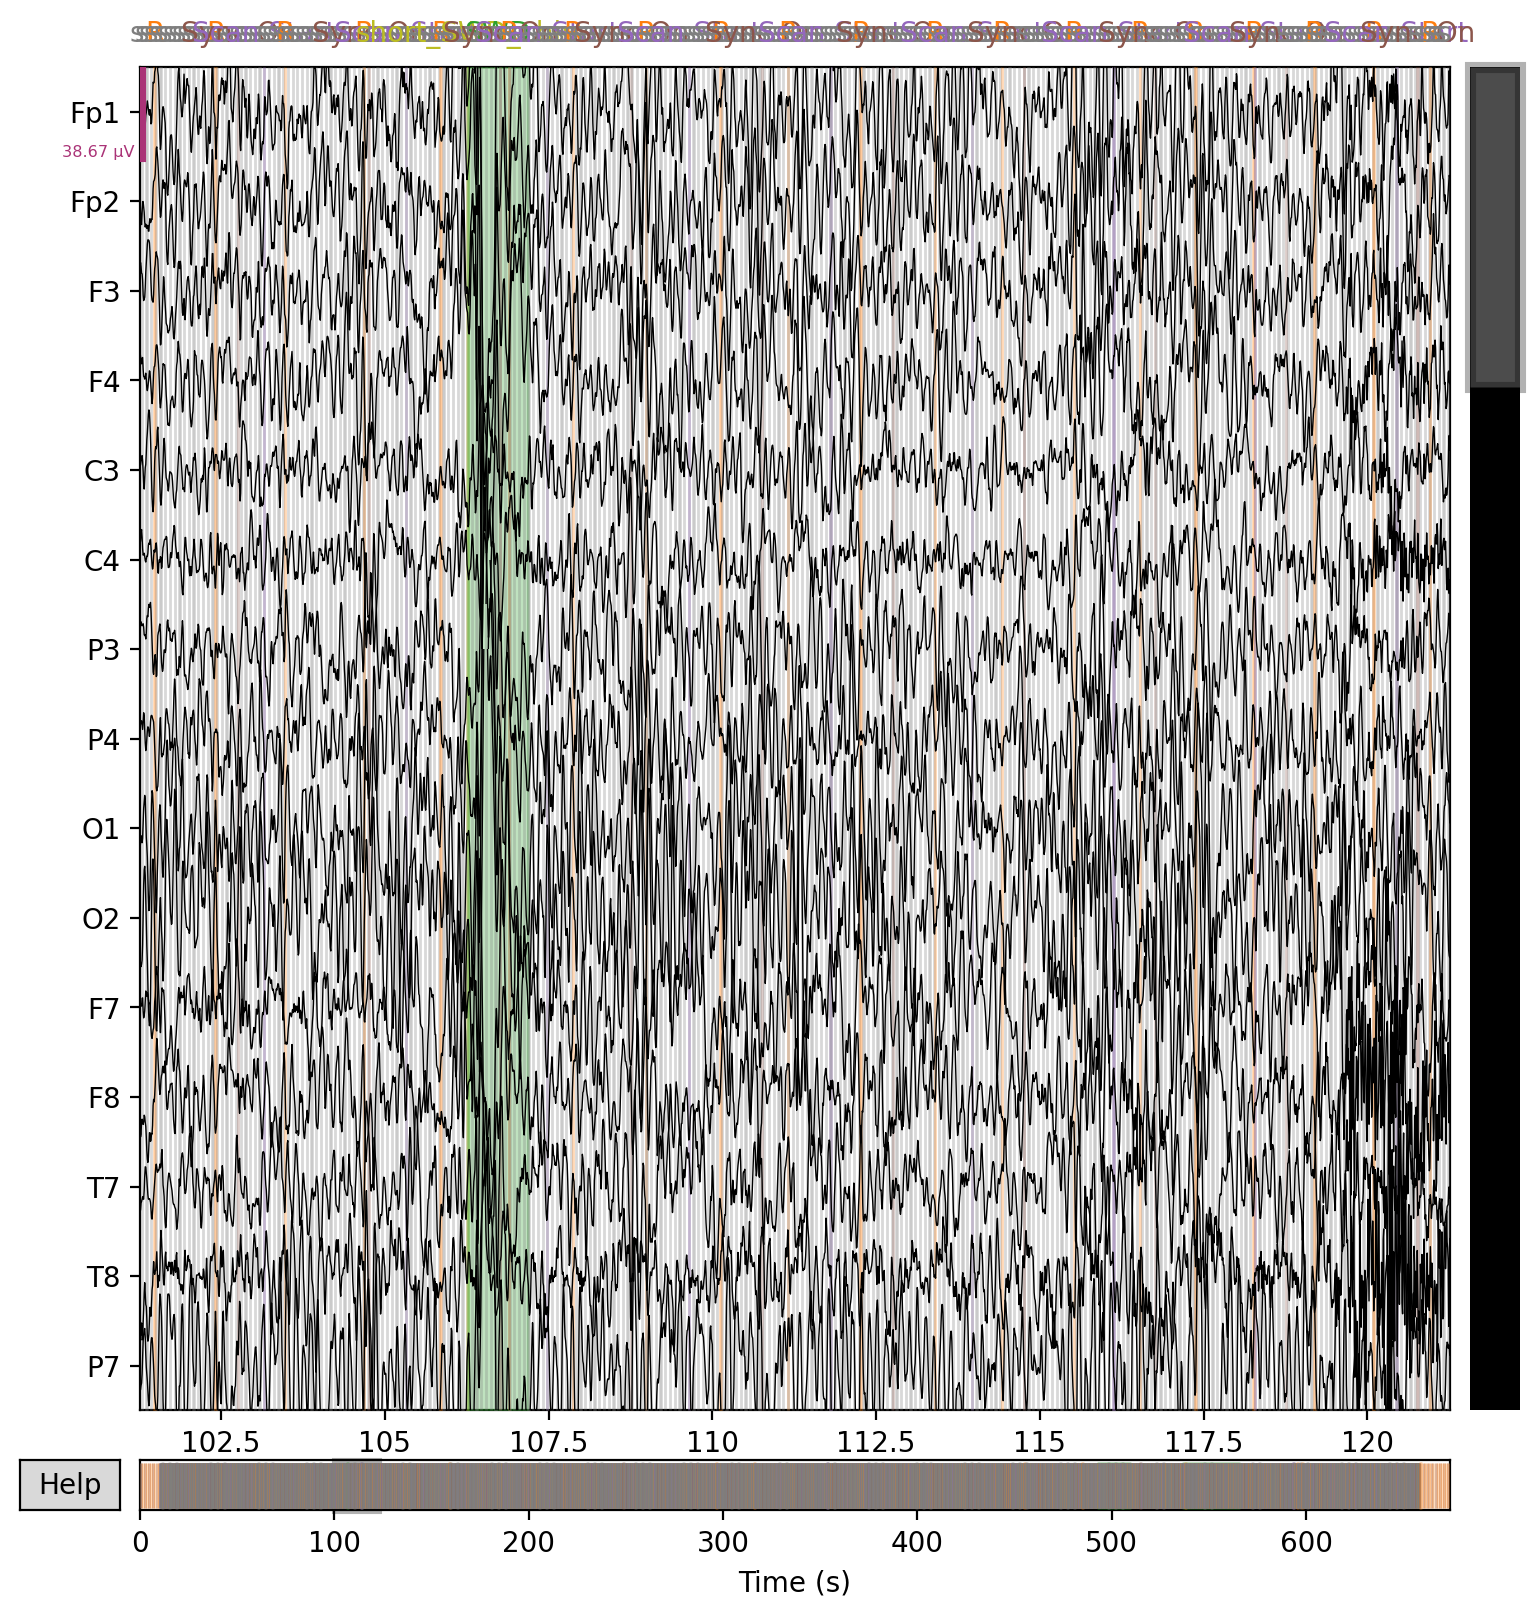

Channels marked as bad:
none


In [20]:
# jumping to first SWD window 
raw.plot(
    start=float(swd.onset[0]) - 5,
    duration=20,
    picks="eeg",
    n_channels=15,
    scalings="auto"
)


In [16]:
# Save the recording-specific SWD annotations in MNE FIF format.
# Only the annotation object is saved; the filtered continuous EEG is not saved here.
ann_path = "AC0003_SWD_annotations.fif"
raw.annotations.save(ann_path, overwrite=True)


Overwriting existing file.
Overwriting existing file.


/var/folders/wg/5rcqnk8978v55y85qslh_jfm0000gn/T/ipykernel_60501/4169079967.py:4: RuntimeWarning: This filename (AC0003_SWD_annotations.fif) does not conform to MNE naming conventions. All annotations files should end with -annot.fif, -annot.fif.gz, _annot.fif, _annot.fif.gz, .txt or .csv
  raw.annotations.save(ann_path, overwrite=True)


In [17]:
# Reload the saved file and recount the SWD events as a write/read integrity check.
ann_check = mne.read_annotations("AC0003_SWD_annotations.fif")
swd_check = ann_check[ann_check.description == "SWD"]
print(len(swd_check))


3


# REPEAT THE ABOVE FOR EACH EEG TRACE